In [17]:
import pandas as pd

team_df=pd.read_csv("Team_data_transformed.csv").iloc[:,1:]
opponent_df=team_df[["code", "XGA", "XGCA", "XGH", "XGCH","kickoff_time"]]

pred_df = pd.merge(team_df, opponent_df, left_on=['opponent', 'kickoff_time'], right_on=['code', 'kickoff_time'], how='left')


Model_pred=pred_df[["name","kickoff_time","was_home","XG","XGC"]]
Model_pred["Own_XG"]=pred_df.apply(lambda row: row[13] if row[6] else row[11], axis=1)
Model_pred["Own_XGC"]=pred_df.apply(lambda row: row[14] if row[6] else row[12], axis=1)
Model_pred["Opposition_XG"]=pred_df.apply(lambda row: row[16] if row[6] else row[18], axis=1)
Model_pred["Opposition_XGC"]=pred_df.apply(lambda row: row[17] if row[6] else row[19], axis=1)

Model_pred.to_csv("Team_data_preds.csv")
import numpy as np
import xgboost as xgb
from datetime import datetime

Model_pred['kickoff_time'] = pd.to_datetime(Model_pred['kickoff_time'])

# Get current year and month
current_year = datetime.today().year
current_month = datetime.today().month

# Filter for current month
test_df = Model_pred[(Model_pred['kickoff_time'].dt.year == current_year) & (Model_pred['kickoff_time'].dt.month == current_month)]
train_df = Model_pred[(Model_pred['kickoff_time'].dt.year < current_year) | 
                 ((Model_pred['kickoff_time'].dt.year == current_year) & (Model_pred['kickoff_time'].dt.month < current_month))]

import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

# Define Features and Target
features = ['Own_XG', 'Own_XGC', 'Opposition_XG', 'Opposition_XGC']  # Exclude target and date
target = 'XG'

X_train = Model_pred[features]
y_train = Model_pred[target]
X_test = Model_pred[features]
y_test = Model_pred[target]

# Initialize and Train XGBoost Model
model_xg = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=60, learning_rate=0.1, max_depth=3,min_child_weight=5)
model_xg.fit(X_train, y_train)

# Make Predictions
y_pred = model_xg.predict(X_test)
print(X_test)
print(y_pred)
# Evaluate Performance
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error on Test Set: {mse:.4f}")


import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

# Define Features and Target
features = ['Own_XG', 'Own_XGC', 'Opposition_XG', 'Opposition_XGC']  # Exclude target and date
target = 'XGC'

X_train = Model_pred[features]
y_train = Model_pred[target]
X_test = Model_pred[features]
y_test = Model_pred[target]

# Initialize and Train XGBoost Model
model_xgc = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=60, learning_rate=0.1, max_depth=3,min_child_weight=5)
model_xgc.fit(X_train, y_train)

# Make Predictions
y_pred = model_xgc.predict(X_test)
print(X_test)
print(y_pred)
# Evaluate Performance
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error on Test Set: {mse:.4f}")

fixture_data=pd.read_csv("Raw_Data_24/Fantasy_season_2024_Fixtures.csv")[["event","team_a","team_h","finished"]]
team_code_data=pd.read_csv("Fantasy-Premier-League/Fantasy-Premier-League/data/2024-25/teams2.csv")[["name","code","id"]]
team_data=pd.read_csv("Team_data_newest.csv")[["code","XGA","XGCA","XGH","XGCH"]]
fixture_data=fixture_data[fixture_data["finished"]==False]

min_event=fixture_data["event"].min()
horizon=9
min_event_list=[]
for i in range(horizon):
    min_event_list.append(min_event+i)
print(min_event_list)
fixture_data = fixture_data[fixture_data["event"].isin(min_event_list)]


df_merged = fixture_data.merge(team_code_data, left_on='team_a', right_on='id', how='left')  # Left join to keep all rows from df2
df_merged = df_merged.merge(team_code_data, left_on='team_h', right_on='id', how='left')  # Left join to keep all rows from df2
predict_data=df_merged[["event"]]
predict_data["team_a"]=df_merged["code_x"].values
predict_data["team_h"]=df_merged["code_y"].values
predict_data["team_a_name"]=df_merged["name_x"].values
predict_data["team_h_name"]=df_merged["name_y"].values
df_merged = predict_data.merge(team_data[["code","XGA","XGCA"]], left_on='team_a', right_on='code', how='left')  # Left join to keep all rows from df2
df_merged = df_merged.merge(team_data[["code","XGH","XGCH"]], left_on='team_h', right_on='code', how='left')  # Left join to keep all rows from df2

print(df_merged)

new_input = pd.DataFrame()
new_input["Own_XG"]=df_merged["XGH"]
new_input["Own_XGC"]=df_merged["XGCH"]
new_input["Opposition_XG"]=df_merged["XGA"]
new_input["Opposition_XGC"]=df_merged["XGCA"]
xg = model_xg.predict(new_input)
xgc=model_xgc.predict(new_input)

result_df=pd.DataFrame()
result_df["GW"]=df_merged["event"]
result_df["pred"]=df_merged["event"]-min_event+1
result_df["home_team"]=df_merged["team_h_name"]
result_df["away_team"]=df_merged["team_a_name"]
result_df["home_code"]=df_merged["team_h"]
result_df["away_code"]=df_merged["team_a"]
result_df["home_goals"]=xg
result_df["away_goals"]=xgc
result_df.to_csv("Team_prediction_visual.csv")

home_df=result_df[["GW", "pred"]]
home_df["team_name"]=result_df["home_team"]
home_df["team_code"]=result_df["home_code"]
home_df["XG"]=result_df["home_goals"]
home_df["XGC"]=result_df["away_goals"]

away_df=result_df[["GW", "pred"]]
away_df["team_name"]=result_df["away_team"]
away_df["team_code"]=result_df["away_code"]
away_df["XG"]=result_df["away_goals"]
away_df["XGC"]=result_df["home_goals"]

ALL_pred=pd.concat([home_df, away_df], axis=0, ignore_index=True)
ALL_pred.to_csv("Team_prediction.csv")
print(ALL_pred)


C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_23436\4218560518.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Model_pred["Own_XG"]=pred_df.apply(lambda row: row[13] if row[6] else row[11], axis=1)
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_23436\4218560518.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Model_pred["Own_XG"]=pred_df.apply(lambda row: row[13] if row[6] else row[11], axis=1)
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_23436\4218560518.py:11: FutureWarning: Series.__getitem__ treating keys as positions is d

        Own_XG   Own_XGC  Opposition_XG  Opposition_XGC
0     1.500000  1.500000       1.500000        1.500000
1     1.250000  2.500000       1.250000        1.250000
2     1.250000  3.125000       1.750000        2.375000
3     1.833333  2.083333       0.333333        2.833333
4     1.125000  1.687500       0.875000        1.500000
...        ...       ...            ...             ...
2077  0.782292  1.916354       0.708958        2.133958
2078  0.946771  2.075729       1.552292        1.191771
2079  0.830208  1.966146       1.473542        1.592500
2080  0.988646  2.043229       1.370104        1.659792
2081  0.983750  1.908229       1.672500        1.273750

[2082 rows x 4 columns]
[1.3612436 1.1698891 1.7168217 ... 0.9672563 1.1938372 1.1602621]
Mean Squared Error on Test Set: 0.7575
        Own_XG   Own_XGC  Opposition_XG  Opposition_XGC
0     1.500000  1.500000       1.500000        1.500000
1     1.250000  2.500000       1.250000        1.250000
2     1.250000  3.125000      

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_23436\4218560518.py:101: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predict_data["team_a"]=df_merged["code_x"].values
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_23436\4218560518.py:102: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predict_data["team_h"]=df_merged["code_y"].values
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_23436\4218560518.py:103: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a

112
['Fábio_Ferreira Vieira' 'Gabriel_Fernando de Jesus'
 'Gabriel_dos Santos Magalhães' 'Kai_Havertz' 'Jurriën_Timber'
 'Jorge_Luiz Frello Filho' 'Jakub_Kiwior' 'Gabriel_Martinelli Silva'
 'Ethan_Nwaneri' 'Martin_Ødegaard' 'David_Raya Martin' 'Declan_Rice'
 'Bukayo_Saka' 'William_Saliba' 'Thomas_Partey' 'Kieran_Tierney'
 'Leandro_Trossard' 'Benjamin_White' 'Oleksandr_Zinchenko'
 'Raheem_Sterling' 'Riccardo_Calafiori' 'Myles_Lewis-Skelly'
 'Mikel_Merino' 'Leon_Bailey' 'Ross_Barkley' 'Emiliano_Buendía Stati'
 'Matty_Cash' 'Leander_Dendoncker' 'Moussa_Diaby'
 'Diego_Carlos Santos Silva' 'Lucas_Digne' 'Jhon_Durán' 'Boubacar_Kamara'
 'Ezri_Konsa Ngoyo' 'Ian_Maatsen' 'Emiliano_Martínez Romero' 'John_McGinn'
 'Tyrone_Mings' 'Kosta_Nedeljković' 'Robin_Olsen' 'Pau_Torres'
 'Jacob_Ramsey' 'Morgan_Rogers' 'Youri_Tielemans' 'Ollie_Watkins'
 'Amadou_Onana' 'Jaden_Philogene' 'Lamare_Bogarde' 'Max_Aarons'
 'Tyler_Adams' 'Jaidon_Anthony' 'David_Brooks' 'Ryan_Christie'
 'Lewis_Cook' 'Enes_Ünal' 'Hamed

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_23436\3008186354.py:50: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  opp_xg = data.apply(lambda row: row[22] if row[18] else row[20], axis=1)
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_23436\3008186354.py:51: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  opp_xgc = data.apply(lambda row: row[23] if row[18] else row[21], axis=1)


Fábio_Ferreira Vieira
Gabriel_Fernando de Jesus
Gabriel_dos Santos Magalhães
Kai_Havertz0
Kai_Havertz1
Jurriën_Timber
Jorge_Luiz Frello Filho0
Jorge_Luiz Frello Filho1
Jakub_Kiwior
Gabriel_Martinelli Silva
Ethan_Nwaneri
Martin_Ødegaard
David_Raya Martin0
David_Raya Martin1
Declan_Rice0
Declan_Rice1
Bukayo_Saka
William_Saliba
Thomas_Partey
Kieran_Tierney
Leandro_Trossard0
Leandro_Trossard1
Benjamin_White
Oleksandr_Zinchenko
Raheem_Sterling0
Raheem_Sterling1
Riccardo_Calafiori
Myles_Lewis-Skelly
Mikel_Merino
Leon_Bailey
Ross_Barkley0
Ross_Barkley1
Emiliano_Buendía Stati
Matty_Cash
Leander_Dendoncker0
Leander_Dendoncker1
Moussa_Diaby
Diego_Carlos Santos Silva
Lucas_Digne
Jhon_Durán
Boubacar_Kamara
Ezri_Konsa Ngoyo
Ian_Maatsen0
Ian_Maatsen1
Emiliano_Martínez Romero
John_McGinn
Tyrone_Mings
Kosta_Nedeljković


C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_23436\3008186354.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XG"]=team_stats["XG"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_23436\3008186354.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XGC"]=team_stats["XGC"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_23436\3008186354.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

Robin_Olsen
Pau_Torres
Jacob_Ramsey
Morgan_Rogers
Youri_Tielemans0
Youri_Tielemans1
Ollie_Watkins
Amadou_Onana0
Amadou_Onana1
Jaden_Philogene0
Jaden_Philogene1
Lamare_Bogarde
Max_Aarons
Tyler_Adams0
Tyler_Adams1
Jaidon_Anthony
David_Brooks
Ryan_Christie
Lewis_Cook
Enes_Ünal
Hamed_Traorè
James_Hill
Milos_Kerkez
Justin_Kluivert
Chris_Mepham
Dango_Ouattara
Philip_Billing
Alex_Scott
Antoine_Semenyo
Marcos_Senesi
Luis_Sinisterra
Adam_Smith
Marcus_Tavernier
Mark_Travers
Illia_Zabarnyi
Kepa_Arrizabalaga0
Kepa_Arrizabalaga1
Dean_Huijsen
Julián_Araujo Zúñiga
Francisco_Evanilson de Lima Barbosa
Kristoffer_Ajer
Nathan_Collins0
Nathan_Collins1
Mikkel_Damsgaard
Josh_Dasilva
Mark_Flekken
Rico_Henry
Aaron_Hickey
Vitaly_Janelt
Mathias_Jensen


...

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_23436\3008186354.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XG"]=team_stats["XG"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_23436\3008186354.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XGC"]=team_stats["XGC"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_23436\3008186354.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

Pascal_Struijk
Theo_Walcott
Marc_Roca Junqué
Vladimir_Coufal
Rasmus_Kristensen
Jack_Colback
Romain_Perraud
João_Filipe Iria Santos Moutinho
Çaglar_Söyüncü
Joel_Robles
Renan_Augusto Lodi dos Santos
Denis_Zakaria
Duje_Caleta-Car
Wilfried_Gnonto
Diego_Da Silva Costa
Maximilian_Wöber
Carlos_Alcaraz
Wout_Weghorst
Keylor_Navas
Arnaut_Danjuma
Sasa_Lukic
Matías_Viña
Weston_McKennie
Mateus_Cardoso Lemos Martins
Marcel_Sabitzer
André_Ayew


C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_23436\3008186354.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XG"]=team_stats["XG"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_23436\3008186354.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XGC"]=team_stats["XGC"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_23436\3008186354.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

XG_Mean_difference


C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_23436\3008186354.py:298: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  extra['name'] = extra['name'].astype(str) + 'r'
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_23436\3008186354.py:299: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  extra['name'] = extra['name'].astype('category')
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_23436\3008186354.py:304: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Da

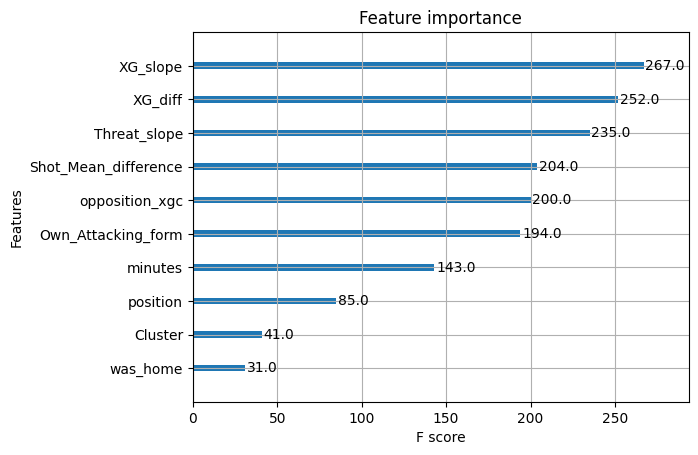

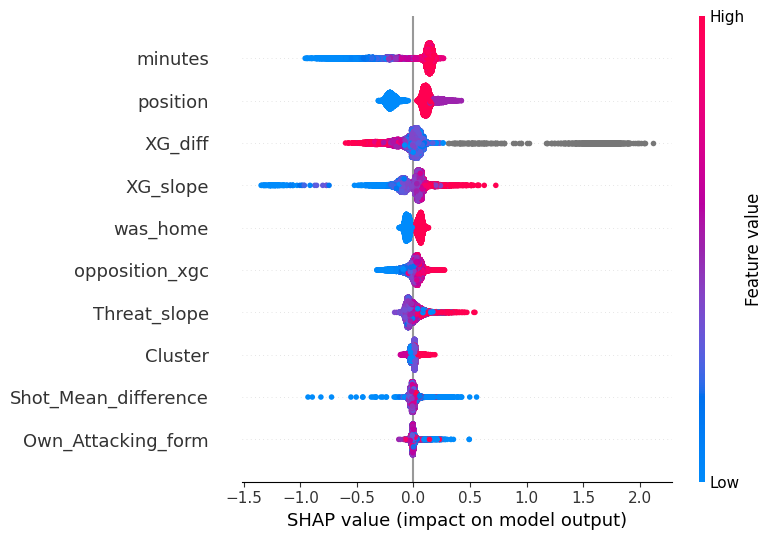

tensor(0.0898, dtype=torch.float64)


C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_23436\3008186354.py:50: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  opp_xg = data.apply(lambda row: row[22] if row[18] else row[20], axis=1)
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_23436\3008186354.py:51: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  opp_xgc = data.apply(lambda row: row[23] if row[18] else row[21], axis=1)


Fábio_Ferreira Vieira
Gabriel_Fernando de Jesus
Gabriel_dos Santos Magalhães
Kai_Havertz0
Kai_Havertz1
Jurriën_Timber
Jorge_Luiz Frello Filho0
Jorge_Luiz Frello Filho1
Jakub_Kiwior
Gabriel_Martinelli Silva
Ethan_Nwaneri
Martin_Ødegaard
David_Raya Martin0
David_Raya Martin1
Declan_Rice0
Declan_Rice1
Bukayo_Saka
William_Saliba
Thomas_Partey
Kieran_Tierney
Leandro_Trossard0
Leandro_Trossard1
Benjamin_White
Oleksandr_Zinchenko
Raheem_Sterling0
Raheem_Sterling1
Riccardo_Calafiori
Myles_Lewis-Skelly
Mikel_Merino
Leon_Bailey
Ross_Barkley0
Ross_Barkley1
Emiliano_Buendía Stati
Matty_Cash
Leander_Dendoncker0
Leander_Dendoncker1
Moussa_Diaby
Diego_Carlos Santos Silva
Lucas_Digne
Jhon_Durán
Boubacar_Kamara
Ezri_Konsa Ngoyo
Ian_Maatsen0
Ian_Maatsen1
Emiliano_Martínez Romero
John_McGinn


C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_23436\3008186354.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XG"]=team_stats["XG"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_23436\3008186354.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XGC"]=team_stats["XGC"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_23436\3008186354.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

Tyrone_Mings
Kosta_Nedeljković
Robin_Olsen
Pau_Torres
Jacob_Ramsey
Morgan_Rogers
Youri_Tielemans0
Youri_Tielemans1
Ollie_Watkins
Amadou_Onana0
Amadou_Onana1
Jaden_Philogene0
Jaden_Philogene1
Lamare_Bogarde
Max_Aarons
Tyler_Adams0
Tyler_Adams1
Jaidon_Anthony
David_Brooks
Ryan_Christie
Lewis_Cook
Enes_Ünal
Hamed_Traorè
James_Hill
Milos_Kerkez
Justin_Kluivert
Chris_Mepham
Dango_Ouattara
Philip_Billing
Alex_Scott
Antoine_Semenyo
Marcos_Senesi
Luis_Sinisterra
Adam_Smith
Marcus_Tavernier
Mark_Travers
Illia_Zabarnyi
Kepa_Arrizabalaga0
Kepa_Arrizabalaga1
Dean_Huijsen
Julián_Araujo Zúñiga
Francisco_Evanilson de Lima Barbosa
Kristoffer_Ajer
Nathan_Collins0
Nathan_Collins1
Mikkel_Damsgaard
Josh_Dasilva


...

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_23436\3008186354.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XG"]=team_stats["XG"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_23436\3008186354.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XGC"]=team_stats["XGC"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_23436\3008186354.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

Rasmus_Kristensen
Jack_Colback
Romain_Perraud
João_Filipe Iria Santos Moutinho
Çaglar_Söyüncü
Joel_Robles
Renan_Augusto Lodi dos Santos
Denis_Zakaria
Duje_Caleta-Car
Wilfried_Gnonto
Diego_Da Silva Costa
Maximilian_Wöber
Carlos_Alcaraz
Wout_Weghorst
Keylor_Navas
Arnaut_Danjuma
Sasa_Lukic
Matías_Viña
Weston_McKennie
Mateus_Cardoso Lemos Martins
Marcel_Sabitzer
André_Ayew


C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_23436\3008186354.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XG"]=team_stats["XG"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_23436\3008186354.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["team_XGC"]=team_stats["XGC"].values[:horizon]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_23436\3008186354.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

XA_Mean_difference


C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_23436\3008186354.py:298: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  extra['name'] = extra['name'].astype(str) + 'r'
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_23436\3008186354.py:299: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  extra['name'] = extra['name'].astype('category')
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_23436\3008186354.py:304: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Da

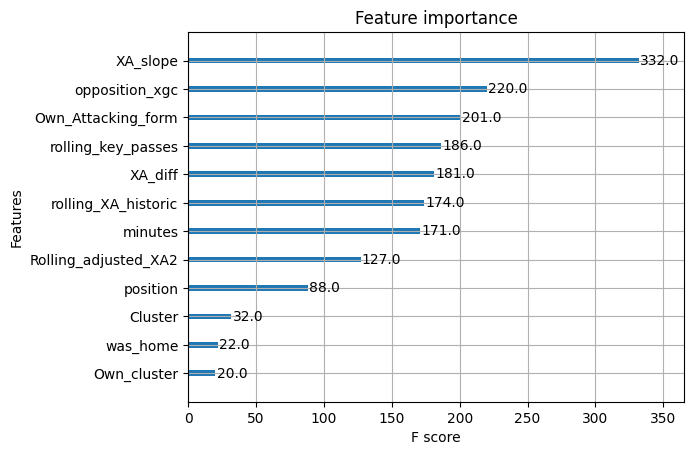

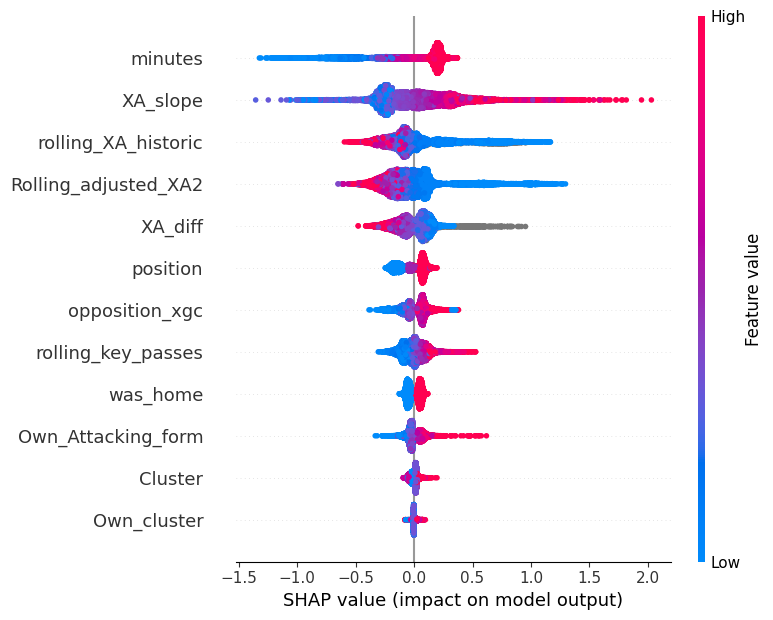

tensor(0.0530, dtype=torch.float64)


In [35]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from datetime import datetime, timedelta
from sklearn.preprocessing import LabelEncoder
import pytz
import torch.nn as nn
import torch
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import load_model
from tensorflow.keras.models import load_model
from tensorflow.keras.losses import MeanSquaredError

criterion = nn.L1Loss()
df=pd.read_csv("testML3.csv").iloc[:,1:]
max_t=df['time'].max()
print(max_t)
names= df['name'].unique()
print(names)
time_df=pd.DataFrame()
for i in range(len(names)):
    name=names[i]
    first_filtered= df[df['name'] == name]
    unique_teamvals= first_filtered['Team'].unique()
    for t in range(len(unique_teamvals)):
        team=unique_teamvals[t]
        new_filtered= first_filtered[first_filtered['Team'] == team]
        times=[]
        filtered = new_filtered[new_filtered["minutes"] > 0]
        for g in range(len(filtered)):
            times.append(max_t-g)
        times.reverse()
        filtered["time"]=times
        if(len(unique_teamvals)>1):
            filtered['name']=filtered['name'].values[0]+str(t)
        time_df=pd.concat([time_df, filtered], axis=0, ignore_index=True)

time_df.to_csv("ML_training2.csv")
def Stat_preds(is_pred, pred_variable):
    horizon=8
    data=pd.read_csv("ML_training2.csv").iloc[:,1:]
    team_data=pd.read_csv("Team_prediction.csv").iloc[:,1:]
    max_time=data["time"].max()
    if(is_pred==0):
        max_time=max_time-horizon
    time_list=list(range(max_time, max_time-horizon, -1))
    opp_xg = data.apply(lambda row: row[22] if row[18] else row[20], axis=1)
    opp_xgc = data.apply(lambda row: row[23] if row[18] else row[21], axis=1)
    data["opposition_xg"]=opp_xg
    data["opposition_xgc"]=opp_xgc
    data['rolling_Threat'] = data['rolling_Threat'].fillna(10)
    data['rolling_key_passes'] = data['rolling_key_passes'].fillna(0.5)
    data['rolling_ICT'] = data['rolling_ICT'].fillna(5)
    
    pred_data=data[data['time'].isin(time_list)]
    players=data["name"].unique()
    all_preds=[]
    MSE=[]
    for i in range(len(players)):
        print(players[i])
        preds=[]
        val_preds=[]
        val_real=[]
        df=pred_data[pred_data["name"]==players[i]]
        team=df['Team'].values[-1]
        team_stats=team_data[team_data["team_code"]==team].sort_values(by='pred')
        if(len(team_stats)<1):
            continue
        df["team_XG"]=team_stats["XG"].values[:horizon]
        df["team_XGC"]=team_stats["XGC"].values[:horizon]
        df=df.sort_values(by='time')
        df2=data[data["name"]==players[i]]
        season_filter=df2[(df2['season'] == 25)]
        if(len(season_filter)<1):
            continue
        if(pred_variable=="GOALS"):
           df["pred"]=(df['Rolling_adjusted_XG2']*(df['team_XG'])*0.5+0.004*df['rolling_Threat'])*(1+df['XG_slope'])
           real_variable="expected_goals" 
        if(pred_variable=="Assist"):
           real_variable="expected_assists"  
           df["pred"]=(df['Rolling_adjusted_XA2']*(df['team_XG']) *0.6+0.035*df['rolling_key_passes'])*(1+df['XA_slope'])
            
        if(pred_variable=="GC"):
            real_variable="expected_goals_conceded"
            if(df["position"].values[0] in ["FWD","MID"]):
                continue
            team=df['Team'].values[-1]
            time_filter = data[(data['season'] == 25)]
            team_filter=time_filter[time_filter["Team"]==team]
            team_filter = team_filter.groupby('name')['minutes'].sum().reset_index()
            if(len(team_filter)<1):
                continue
            else:
                player_with_most_minutes = team_filter.loc[team_filter['minutes'].idxmax(), 'name']
                filtered_df=data[data["name"]==player_with_most_minutes]
                filtered_df = filtered_df[(filtered_df['season'] == 30)]

            df["pred"]=df["team_XGC"].values
            
        if(pred_variable=="bps"):
           real_variable="bonus" 
           df["pred"]=df['Rolling_adjusted_BPS2']*0.04
        
        if(pred_variable=="Fantasy"):
           real_variable="total_points"  
           df["pred"]=df['Rolling_adjusted_Fantasy2']*(df['team_XG'])
            
        preds.append(df["name"].values[0])
        df["pred"]=df["pred"].round(2)
        #if(df['pred'].isna().any()):
            #continue
        for r in range(len(df.values)):
            preds.append(df["pred"].values[r])
            val_preds.append(df["pred"].values[r])
            val_real.append(df[real_variable].values[r])
            
        preds.append(df["position"].values[0])
        all_preds.append(preds)
        #MSE.append(mean_squared_error(val_real, val_preds))
        
    columns=["Name","p1","p2","p3","p4","p5","p6","p7","p8","position"]
    data_f=pd.DataFrame(all_preds, columns=columns)
    data_f.to_csv(f"STAT_{pred_variable}_preds2.csv", index=False)
    #print(sum(MSE) / len(MSE))
def XGB_Make_dataset(position,position2):
    df=pd.read_csv("ML_training2.csv").iloc[:,1:]
    #df=df[df['position'] == position2]
    if(position in['Assist','GOALS']):
        df = df.dropna(subset=['XG_Mean_difference', 'XA_Mean_difference'])
    opp_xg = df.apply(lambda row: row[22] if row[18] else row[20], axis=1)
    opp_xgc = df.apply(lambda row: row[23] if row[18] else row[21], axis=1)

    df["opposition_xg"]=opp_xg
    df["opposition_xgc"]=opp_xgc

    trainingdf=df[["Threat_slope","XA_slope","XG_slope","minutes","season","opposition_xg","Average_Overscore","opposition_xgc", "rolling_form","rolling_XG","Team","name","position","Own_cluster","Cluster"
                   ,"was_home","total_points","rolling_GS","rolling_GC","rolling_XA","time","gamepos","rolling_ICT","Overscore","XGC_DEF","XGC_FWD","XGC_MID"
                   ,"Rolling_adjusted_XG2","Rolling_adjusted_XGC2","Rolling_adjusted_XA2","rolling_GS_historic","rolling_XG_historic","goals_scored","expected_goals"
                  ,"assists","rolling_Assist_historic","rolling_Assist","rolling_XA_historic","expected_assists","rolling_GC_historic","rolling_XGC_historic","clean_sheets",
                   "expected_goals_conceded", "rolling_bps","rolling_bps_historic","rolling_bonus_historic","rolling_bonus","bonus","rolling_key_passes","rolling_shots","Own_Attacking_form","Rolling_BPS_per_90"
                  ,"XG_Mean_difference","XA_Mean_difference","Shot_Mean_difference","Adjusted_XG_Mean_difference","Threat_Mean_difference","rolling_Threat","XG_Mean"]]
    
    
    names= df['name'].unique()
    time_df=pd.DataFrame()
    for i in range(len(names)):
        times=[]
        name=names[i]
        filtered= trainingdf[trainingdf['name'] == name].copy()
        filtered['rolling_XG'] = filtered['rolling_XG'].shift(1)
        filtered['rolling_GC'] = filtered['rolling_GC'].shift(1)
        filtered['rolling_XA'] = filtered['rolling_XA'].shift(1)
        filtered['rolling_GS_historic'] = filtered['rolling_GS_historic'].shift(1)
        filtered['rolling_XG_historic'] = filtered['rolling_XG_historic'].shift(1)
        filtered['rolling_XA_historic'] = filtered['rolling_XA_historic'].shift(1)
        filtered['rolling_Assist'] = filtered['rolling_Assist'].shift(1)
        filtered['rolling_Assist_historic'] = filtered['rolling_Assist_historic'].shift(1)
        filtered['rolling_bps'] = filtered['rolling_bps'].shift(1)
        #filtered['Rolling_adjusted_XGC'] = filtered['Rolling_adjusted_XGC'].shift(1)
        #filtered['Rolling_adjusted_XG'] = filtered['Rolling_adjusted_XG'].shift(1)
        filtered['Overscore'] = filtered['Overscore'].shift(1)
        filtered['Capped_Average_Overscore'] = np.clip(df['Average_Overscore'], None, 1.5)
        filtered['Future_XG'] = filtered['Rolling_adjusted_XG2']*filtered['opposition_xgc']
        filtered['Future_XG2'] = filtered['Rolling_adjusted_XG2']*(filtered['opposition_xgc']*0.8+0.1*filtered['Own_Attacking_form']**2)
        
        filtered['Future_XGC'] = filtered['Rolling_adjusted_XGC2']*filtered['opposition_xg']
        filtered['Future_XGA'] = filtered['Rolling_adjusted_XA2']*filtered['opposition_xgc']
        filtered['XG_diff'] = filtered["rolling_XG"]-filtered['rolling_XG_historic']
        filtered['XA_diff'] = filtered["rolling_XA"]-filtered['rolling_XA_historic']
        filtered['opposition_xgc_bucket'] = pd.cut(filtered['opposition_xgc'],bins=[0, 0.8, 1, 1.2,1.3 ,1.4,1.5 ,1.6, 1.8, 2, 3],labels=[0.4, 0.9, 1.1, 1.2,1.3, 1.5,1.6, 1.7, 1.9, 2.5],include_lowest=True)
        filtered['opposition_xg_bucket'] = pd.cut(filtered['opposition_xg'],bins=[0, 0.8, 1, 1.2,1.3 ,1.4,1.5 ,1.6, 1.8, 2, 3],labels=[0.4, 0.9, 1.1, 1.2,1.3, 1.5,1.6, 1.7, 1.9, 2.5],include_lowest=True)

        filtered['Own_Attacking_form_bucket'] = pd.cut(filtered['Own_Attacking_form'],bins=[0, 0.8, 1, 1.2,1.3 ,1.4,1.5 ,1.6, 1.8, 2, 3],labels=[0.4, 0.9, 1.1, 1.2,1.3, 1.5,1.6, 1.7, 1.9, 2.5],include_lowest=True)
        # Convert to numeric (this removes the categorical dtype)
   
        time_df=pd.concat([time_df, filtered], axis=0, ignore_index=True)
    trainingdf=time_df
    trainingdf['Team'] = trainingdf['Team'].astype('category')
    trainingdf['name'] = trainingdf['name'].astype('category')
    trainingdf['opposition_xgc_bucket'] = trainingdf['opposition_xgc_bucket'].astype(float)
    trainingdf['Own_Attacking_form_bucket'] = trainingdf['Own_Attacking_form_bucket'].astype(float)
    trainingdf['opposition_xg_bucket'] = trainingdf['opposition_xg_bucket'].astype(float)
    trainingdf['position'] = trainingdf['position'].astype('category')
    trainingdf['gamepos'] = trainingdf['gamepos'].astype('category')
    trainingdf['Shot_Mean_difference'] = trainingdf['Shot_Mean_difference'].fillna(0)
    trainingdf['Threat_Mean_difference'] = trainingdf['Threat_Mean_difference'].fillna(0)
    trainingdf['Adjusted_XG_Mean_difference'] = trainingdf['Adjusted_XG_Mean_difference'].fillna(0)
    trainingdf['XG_Mean_difference'] = trainingdf['XG_Mean_difference'].clip(lower=-1, upper=2)
    trainingdf['XA_Mean_difference'] = trainingdf['XA_Mean_difference'].clip(lower=-1, upper=3)
    trainingdf.replace([np.inf, -np.inf], 1, inplace=True)
    if(position=='GOALS'):
        trainingdf=trainingdf[trainingdf['position'].isin(["FWD", "DEF", "MID"])]
        trainingdf=trainingdf[["position","XG_diff","opposition_xgc","Own_Attacking_form","Team","name","Cluster"
                   ,"was_home","time","minutes","Shot_Mean_difference","XG_slope","season","XG_Mean_difference","Threat_slope"]]
        target_value="XG_Mean_difference"
        
    elif(position=='Assist'):
        trainingdf=trainingdf[trainingdf['position'].isin(["FWD", "DEF", "MID"])]
        trainingdf=trainingdf[["XA_diff","position","opposition_xgc","Own_Attacking_form","Rolling_adjusted_XA2","Team","name","Own_cluster","Cluster"
                   ,"was_home","time","minutes","rolling_XA_historic","XA_Mean_difference","season","rolling_key_passes","XA_slope"]]
        target_value="XA_Mean_difference"
        
    elif(position=='GC'):
        trainingdf=trainingdf[trainingdf['position'] == "DEF"]
        trainingdf=trainingdf[["position","opposition_xg","Rolling_adjusted_XGC2","Team","name","Own_cluster","Cluster"
                   ,"was_home","rolling_GC","time","minutes","Future_XGC","rolling_GC_historic","rolling_XGC_historic","expected_goals_conceded","season"]]
        target_value="expected_goals_conceded"
        
    elif(position=='bps'):
        trainingdf=trainingdf[["opposition_xgc","position","opposition_xg","Own_Attacking_form","rolling_bonus_historic","rolling_bonus","bonus","Team","name","Own_cluster","Cluster"
                   ,"was_home","time","minutes","season","Future_XG","Future_XGA","Future_XGC","Rolling_BPS_per_90"]]
        target_value="bonus"
        
    elif(position=='Fantasy'):
        trainingdf=trainingdf[["total_points","opposition_xg","opposition_xgc","position","Own_Attacking_form","rolling_bonus","Team","name","Own_cluster","Cluster"
                   ,"was_home","time","minutes","season","Future_XG","Future_XGA","Future_XGC","Rolling_adjusted_XA2","rolling_key_passes","rolling_Assist","Rolling_adjusted_XG2"
                    ,"rolling_GS","rolling_GS_historic","Rolling_adjusted_XGC2","rolling_GC","rolling_form","Rolling_BPS_per_90"]]
        target_value="total_points"
        
    elif(position=='GK'):
        trainingdf=trainingdf[["opposition_xg","Team","name","Own_cluster","Cluster"
                   ,"was_home","total_points","rolling_GC","time","gamepos"]]
        
    elif(position=='GOALS2'):
        trainingdf=trainingdf[trainingdf['position'].isin(["FWD", "DEF", "MID"])]
        trainingdf=trainingdf[["expected_goals","opposition_xgc","Own_Attacking_form",
                               "Team","name","time","minutes","season","rolling_Threat","position","rolling_XG_historic","Cluster","Rolling_adjusted_XG2"]]
        target_value="expected_goals"   

    else:
        trainingdf=trainingdf[["opposition_xg","opposition_xgc", "rolling_form","rolling_XG","Team","name","Own_cluster","Cluster"
                   ,"was_home","total_points","rolling_GS","rolling_XA","time","gamepos",'Future_XG',"Future_XGA"]]
    trainingdf.to_csv("xgb_test_data.csv")
    print(target_value)
    return trainingdf,target_value
    
def XGB_Train(rounds, eta,max_depth,gamma,min_c,dtrain,target_value,train,Y_train  ):
    if(target_value=='bonus'):
        params = {
            'objective': 'multi:softprob',
            'max_depth': max_depth,
            'eta': eta,
            'eval_metric': 'mlogloss',
            'tree_method': 'hist',
            'grow_policy': 'lossguide',
            'lambda': 2,
            'gamma': gamma,
            'min_child_weight': min_c,
            'num_class': 4
        }

        # Train using xgboost.train
        num_rounds = rounds
        xgb_model = xgb.train(params, dtrain, num_rounds)
        return xgb_model

    else:
        params = {
            'max_depth': max_depth,
            'eta': eta,
            'objective': 'reg:squarederror',  # Use 'reg:squarederror' for regression
            'eval_metric': 'rmse',             # Use 'rmse' (root mean squared error) for evaluation
            'tree_method':'hist',
            'grow_policy': 'lossguide',
            'lambda': 2, 
            'gamma':gamma,
            'min_child_weight': min_c
        }

        num_rounds = rounds
        xgb_model = xgb.train(params, dtrain, num_rounds)
        return xgb_model


def XGB_Make_Pred(trainingdf,target_value,position2):
    X_train=pd.DataFrame()
    names= trainingdf['name'].unique()


    for i in range(len(names)):
        name=names[i]
        filtered= trainingdf[trainingdf['name'] == name]
        training_cutoff = filtered["time"].max() - 13

        name_df=filtered[lambda x: x.time <= training_cutoff]
        X_train=pd.concat([X_train, name_df], axis=0, ignore_index=True)
        
    full=['Mohamed_Salah','Kai_Havertz1','Ollie_Watkins','Antoine_Semenyo','Bryan_Mbeumo','João Pedro_Junqueira de Jesus','Danny_Welbeck','Nicolas_Jackson','Jean-Philippe_Mateta','Dominic_Calvert-Lewin','Diogo_Teixeira da Silva'
      ,'Erling_Haaland','Alexander_Isak','Chris_Wood','Matheus_Santos Carneiro Da Cunha','Dominic_Solanke','Gabriel_dos Santos Magalhães','William_Saliba','Lucas_Digne','Ezri_Konsa Ngoyo','Lewis_Dunk','Levi_Colwill0','Antonee_Robinson','Trent_Alexander-Arnold','Andrew_Robertson',
      'Joško_Gvardiol','Rico_Lewis','Diogo_Dalot Teixeira','Dan_Burn','Pedro_Porro','Rayan_Aït-Nouri','Kai_Havertz0','Gabriel_Martinelli Silva','Bukayo_Saka','Martin_Ødegaard','Morgan_Rogers','Antoine_Semenyo','Marcus_Tavernier','Bryan_Mbeumo','Noni_Madueke',
      'Cole_Palmer0','Eberechi_Eze','Dwight_McNeil','Diogo_Teixeira da Silva','Luis_Díaz','Mohamed_Salah','Phil_Foden','Bruno_Borges Fernandes','Marcus_Rashford','Harvey_Barnes1','Anthony_Gordon0',
      'Morgan_Gibbs-White0','Brennan_Johnson0','Dejan_Kulusevski','James_Maddison1','Jarrod_Bowen']
    
    extra=X_train[X_train['name'].isin(full)]
    extra['name'] = extra['name'].astype(str) + 'r'
    extra['name'] = extra['name'].astype('category')
    X_train=pd.concat([X_train, extra], axis=0, ignore_index=True)

    full=['Mohamed_Salah']
    extra=X_train[X_train['name'].isin(full)]
    extra['name'] = extra['name'].astype(str) + 'r2'
    extra['name'] = extra['name'].astype('category')
    X_train=pd.concat([X_train, extra], axis=0, ignore_index=True)
    
    X_test=pd.DataFrame()

    max_cutoff=8
    min_cutoff=0
    for i in range(len(names)):
        name=names[i]
        filtered= trainingdf[trainingdf['name'] == name]
        training_cutoff = filtered["time"].max() - max_cutoff
        training_cutoff2 = filtered["time"].max() - min_cutoff
        name_df=filtered[lambda x: x.time > training_cutoff]
        name_df=name_df[lambda x: x.time <= training_cutoff2]
        X_test=pd.concat([X_test, name_df], axis=0, ignore_index=True)

    total=[]
    
    Y_train=X_train[[target_value]]
    Y_test=X_test[[target_value]]

    train = X_train.drop(columns=[target_value,'time',"name","Team","season"])
    test = X_test.drop(columns=['time'])

    dtrain = xgb.DMatrix(train, label=Y_train,enable_categorical=True)

    dtest = xgb.DMatrix(test, label=Y_test,enable_categorical=True)



    preds_list=test['name'].unique()
    test.to_csv("Debugg.csv")
    model=XGB_Train(60,0.1,5,0.1,6,dtrain,target_value,train,Y_train )
    row2=[]
    actuals=[]
    df2=pd.read_csv("ML_training2.csv").iloc[:,1:]
    for i in range(len(preds_list)):
        row=[]
        player=[]
        player.append(preds_list[i])
        row.append(preds_list[i])
        filtered_df = test[test['name'].isin(player)]
        min_cutoff=max(min_cutoff,1)
        xg_mean=df2[df2['name'].isin(player)]["XG_Mean"]
        xa_mean=df2[df2['name'].isin(player)]["XA_Mean"]
        xg=df2[df2['name'].isin(player)]["expected_goals"]
        xa=df2[df2['name'].isin(player)]["expected_assists"]
        if(target_value=="expected_goals_conceded"):
            team=filtered_df['Team'].values[-1]
            
            team_filter=trainingdf[trainingdf["Team"]==team]
            time_filter = team_filter[team_filter['season'] == 25]
            if(len(time_filter)<1):
                continue
            else:
                player_with_most_minutes = time_filter.loc[time_filter['minutes'].idxmax(), 'name']
                print(player_with_most_minutes)
                filtered_df=test[test["name"]==player_with_most_minutes]
        filtered.drop(columns=['time'])
        y=filtered_df[[target_value]]
        filtered_df = filtered_df.drop(columns=[target_value,'name',"Team","season"])
        dtest = xgb.DMatrix(filtered_df, label=y,enable_categorical=True)
        y_pred = model.predict(dtest)
        for g in range(len(y_pred)):
            
            if(target_value=="XG_Mean_difference"):
                row.append(y_pred[g]*xg_mean.values[-(max_cutoff-g)]+xg_mean.values[-(max_cutoff-g)])
                row2.append(y_pred[g]*xg_mean.values[-(max_cutoff-g)]+xg_mean.values[-(max_cutoff-g)])
                #row.append(y_pred[g])
                #row2.append(y_pred[g])
            elif(target_value=="XA_Mean_difference"):
                row.append(y_pred[g]*xa_mean.values[-(max_cutoff-g)]+xa_mean.values[-(max_cutoff-g)])
                row2.append(y_pred[g]*xa_mean.values[-(max_cutoff-g)]+xa_mean.values[-(max_cutoff-g)])
                #row.append(y_pred[g])
                #row2.append(y_pred[g])
            elif(target_value=="bonus"):
                row.append(y_pred[g][0]*0+y_pred[g][1]*1+y_pred[g][2]*2+y_pred[g][3]*3)
                row2.append(y_pred[g][0]*0+y_pred[g][1]*1+y_pred[g][2]*2+y_pred[g][3]*3)      
            else:
                row.append(y_pred[g])
                row2.append(y_pred[g])
        for t in range(len(y_pred)):
            if(target_value=="XG_Mean_difference"):
                row.append(xg.values[-(max_cutoff-t)])
                actuals.append(xg.values[-(max_cutoff-t)])
                #row.append(y.values[t][0])
                #actuals.append(y.values[t][0])
            elif(target_value=="XA_Mean_difference"):
                row.append(xa.values[-(max_cutoff-t)])
                actuals.append(xa.values[-(max_cutoff-t)])
                #row.append(y.values[t][0])
                #actuals.append(y.values[t][0])

            else:
                row.append(y.values[t][0])
                actuals.append(y.values[t][0])

        row.append(filtered_df["position"].values[0])
        total.append(row)
    from xgboost import plot_importance
    import matplotlib.pyplot as plt
    import shap

    le = LabelEncoder()
    train['position'] = le.fit_transform(train['position'])
    # Plot feature importance
    plot_importance(model, importance_type='weight')
    plt.show()
    if(target_value!="bonus"):
        explainer = shap.Explainer(model)

        # Compute SHAP values
        shap_values = explainer(train)  # X is your feature matrix
        shap.summary_plot(shap_values, train)
    
    print(criterion(torch.tensor(row2), torch.tensor(actuals)))
    columns=["Name","p1","p2","p3","p4","p5","p6","p7","p8","y1","y2","y3","y4","y5","y6","y7","y8","position"]
    data_f=pd.DataFrame(total, columns=columns)
    return data_f
    
def XGB(position,position2):
    data,target_value=XGB_Make_dataset(position,position2)
    pred=XGB_Make_Pred(data,target_value,position2)
    return pred
def Generate_LSTM_preds(pred):
    if(pred in ["GC","Fantasy"]):
        return 0
    data=pd.read_csv("ML_training2.csv").iloc[:,1:]
    opp_xg = data.apply(lambda row: row[22] if row[18] else row[20], axis=1)
    opp_xgc = data.apply(lambda row: row[23] if row[18] else row[21], axis=1)
    data["opposition_xg"]=opp_xg
    data["opposition_xgc"]=opp_xgc
    unique_players=data["name"].unique()
    pred_all_players=pd.DataFrame(columns=["Name", "p1","p2","p3","p4","p5","p6","p7","p8","position"])
    window=8
    for k in range(len(unique_players)):
        pred_player_df=[]
        player_name=unique_players[k]
        
        pred_player_df.append(player_name)
        
        df=data[data["name"]==unique_players[k]]
        position=df["position"].values[-1]
        past_df=df[df["season"]!=30].sort_values(by="time", ascending=True)

        test_df=df[df["season"]==25]
        if(len(test_df)<1):
            continue
        
        if(pred=="GOALS"):
            past_columns=["minutes","shots","Threat","expected_goals"]
            past_columns=["minutes","rolling_XG_historic","Threat","expected_goals"]
            future_columns=["opposition_xgc","Own_Attacking_form"]
            pred_variable="expected_goals"
            model_path="LSTM_Goals2.h5"
        elif(pred=="Assist"):
            past_columns=["minutes","key_passes","creativity","expected_assists"]
            future_columns=["opposition_xgc","Own_Attacking_form"]
            pred_variable="expected_assists"
            model_path="LSTM_Assist2.h5"
        elif(pred=="bps"):
            past_columns=["minutes","ICT","total_points","bonus"]
            future_columns=["opposition_xgc","Own_Attacking_form"]
            pred_variable="bonus"
            model_path="LSTM_Bonus.h5"



        past_df=past_df[past_columns]

        past_scaler = MinMaxScaler(feature_range=(0, 1))
        past_scaler.fit(data[past_columns].to_numpy())
        past_df[past_columns]=past_scaler.transform(past_df[past_columns].to_numpy())

        
        if len(past_df) < window:
            num_missing = window - len(past_df)
            zero_rows = pd.DataFrame(np.zeros((num_missing, past_df.shape[1])), columns=past_df.columns)
            past_df = pd.concat([zero_rows, past_df], ignore_index=True)

        opp_xg = df.apply(lambda row: row[22] if row[18] else row[20], axis=1)
        opp_xgc = df.apply(lambda row: row[23] if row[18] else row[21], axis=1)
        df["opposition_xg"]=opp_xg
        df["opposition_xgc"]=opp_xgc

        future_scaler = MinMaxScaler(feature_range=(0, 1))
        
        future_scaler.fit(data[future_columns].to_numpy())
        df[future_columns]=future_scaler.transform(df[future_columns].to_numpy())
    
        

        future_data=df[df["season"]==30].sort_values(by="time", ascending=True)
        future_data=future_data[future_columns]
        
        if len(future_data) < window:
            num_missing = window - len(future_data)
            zero_rows = pd.DataFrame(np.zeros((num_missing, future_data.shape[1])), columns=future_data.columns)
            future_data = pd.concat([zero_rows, future_data], ignore_index=True)

        
        future=len(future_data)

        past_df=past_df.iloc[-window:,:]

        X_test=[]
        X_future=[]
        for i in range(future): 
            X_test.append(past_df.values)
            X_future.append([future_data.values[i]])

        X_test = np.array(X_test)
        X_future = np.array(X_future)

        if(player_name=="Mohamed_Salah"):
            print(X_test)
            print(X_future)
        # Load the model
        model = load_model(model_path, compile=False)

        # Compile again with the correct loss function
        model.compile(optimizer='adam', loss=MeanSquaredError()) 


        predictions = model.predict([X_test, X_future])

        y_pred_rescaled = past_scaler.inverse_transform(
            np.concatenate((np.zeros((len(predictions), len(past_columns) - 1)), predictions.reshape(-1, 1)), axis=1)
        )[:, -1]

        for y in range(len(y_pred_rescaled)):
            pred_player_df.append(y_pred_rescaled[y])
        pred_player_df.append(position)
        append_df=pd.DataFrame([pred_player_df], columns=["Name", "p1","p2","p3","p4","p5","p6","p7","p8","position"])
        pred_all_players = pd.concat([pred_all_players, append_df], ignore_index=True)

    pred_all_players.to_csv(f"LSTM_{pred}.csv") 
def Make_Predictions ():
    predlength=5
    is_pred=1
    positions=["GOALS", "Assist","GC","bps","Fantasy"]
    positions=["GOALS", "Assist","GC","bps","Fantasy"]
    positions=["GOALS","Assist"]
    for y in range(len(positions)):
        XGB_pred=pd.DataFrame()
        position_filter=positions[y]
        Stat_preds(is_pred, position_filter)

        pred2=XGB(position_filter,"FWD")
        XGB_pred=pd.concat([XGB_pred, pred2], axis=0, ignore_index=True)
            
        XGB_pred.to_csv(f"XGB_{position_filter}_preds2.csv", index=False)
        #Generate_LSTM_preds(position_filter)

if __name__ == '__main__':
    Make_Predictions()
#0.0306
#0.0924

In [19]:
import pandas as pd
import torch
import torch.nn as nn
criterion = nn.MSELoss()
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
data=pd.read_csv("ML_training2.csv").iloc[:,1:]
opp_xg = data.apply(lambda row: row[22] if row[18] else row[20], axis=1)
opp_xgc = data.apply(lambda row: row[23] if row[18] else row[21], axis=1)
data["opposition_xg"]=opp_xg
data["opposition_xgc"]=opp_xgc
data["FXG"]=data['Rolling_adjusted_XG2']*(data['opposition_xgc']*0.8+0.1*data['Own_Attacking_form']**2)
data["FXA"]=data['Rolling_adjusted_XA2']*(data['opposition_xgc']*0.8+0.1*data['Own_Attacking_form']**2) 
data["Fbs"]=data['Rolling_adjusted_BPS']*(data['opposition_xgc']*0.8+0.1*data['Own_Attacking_form'])
data["Fpoints"]=data['Rolling_adjusted_Fantasy2']*(data['opposition_xgc']*0.8+0.1*data['Own_Attacking_form'])
data=data[data["season"]!= 30]

full=['Kai_Havertz1','Ollie_Watkins','Antoine_Semenyo','Bryan_Mbeumo','João Pedro_Junqueira de Jesus','Danny_Welbeck','Nicolas_Jackson','Jean-Philippe_Mateta','Dominic_Calvert-Lewin','Diogo_Teixeira da Silva'
      ,'Erling_Haaland','Alexander_Isak','Chris_Wood1','Matheus_Santos Carneiro Da Cunha','Dominic_Solanke','Gabriel_dos Santos Magalhães','William_Saliba','Lucas_Digne','Ezri_Konsa Ngoyo','Lewis_Dunk','Levi_Colwill0','Antonee_Robinson','Trent_Alexander-Arnold','Andrew_Robertson',
      'Joško_Gvardiol','Rico_Lewis','Diogo_Dalot Teixeira','Dan_Burn','Pedro_Porro','Rayan_Aït-Nouri','Kai_Havertz0','Gabriel_Martinelli Silva','Bukayo_Saka','Martin_Ødegaard','Morgan_Rogers','Antoine_Semenyo','Marcus_Tavernier','Bryan_Mbeumo','Noni_Madueke',
      'Cole_Palmer0','Eberechi_Eze','Dwight_McNeil','Diogo_Teixeira da Silva','Luis_Díaz','Mohamed_Salah','Phil_Foden','Bruno_Borges Fernandes','Marcus_Rashford','Harvey_Barnes1','Anthony_Gordon0',
      'Morgan_Gibbs-White0','Brennan_Johnson0','Dejan_Kulusevski','James_Maddison1','Jarrod_Bowen','Jean-Philippe_Mateta','Kevin_De Bruyne','Morgan_Gibbs-White1','Bernardo_Veiga de Carvalho e Silva','Anthony_Gordon1'
         'Jarrod_Bowen','Lucas_Digne','Son_Heung-min','Dwight_McNeil','Ezri_Konsa Ngoyo','Alex_Iwobi1','Raúl_Jiménez1','Jamie_Vardy','Issa_Diop1','Emile_Smith Rowe1','Yoane_Wissa','Rico_Lewis','Diogo_Dalot Teixeira','Alejandro_Garnacho','Marc_Guéhi',
        'Joël_Veltman','Virgil_van Dijk','Dejan_Kulusevski','Cole_Palmer1','Marcus_Tavernier','Luis_Díaz','Ethan_Pinnock','Marcos_Senesi','Facundo_Buonanotte1','Matheus_Santos Carneiro Da Cunha','Noni_Madueke','Mohammed_Kudus','Murillo_Santiago Costa dos Santos',
         'Daniel_Muñoz','Morgan_Rogers','Mitoma_Kaoru','Ola_Aina','Dominic_Solanke-Mitchell','Jørgen_Strand Larsen','Liam_Delap','Maxence_Lacroix']
data=data[data['name'].isin(full)]



data['FXG'] = data['FXG'].fillna(0)
data['Fbs'] = data['Fbs'].fillna(0)
data['FXA'] = data['FXA'].fillna(0)
data['rolling_Threat'] = data['rolling_Threat'].fillna(5)
data['rolling_ICT'] = data['rolling_ICT'].fillna(3)
data['Fpoints'] = data['Fpoints'].fillna(3)
data['rolling_key_passes'] = data['rolling_key_passes'].fillna(0.5)

"""data_to_scale=data[["rolling_key_passes","rolling_ICT"]]
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_to_scale)
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_data)
pca_df = pd.DataFrame(pca_components, columns=['PC1', 'PC2'])
data["PC1"]=pca_df["PC1"].values
data["PC2"]=pca_df["PC2"].values"""


X_train=data[["Fpoints","rolling_ICT","minutes"]]
y_train=data["total_points"]
linear_regressor = LinearRegression()
linear_regressor.fit(X_train, y_train)
feature_names = X_train.columns
coefficients = linear_regressor.coef_
intercept = linear_regressor.intercept_
for feature, coef in zip(feature_names, coefficients):
    print(f'{feature}: {coef:.4f}')

print(f'Intercept: {intercept:.4f}')
import statsmodels.api as sm

X_train_with_const = sm.add_constant(X_train)
model = sm.OLS(y_train, X_train_with_const).fit()

robust_model = model.get_robustcov_results(cov_type='HC3')
print(robust_model.summary())
#R 0.183
#AIC -1.35

C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_23436\2054453387.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  opp_xg = data.apply(lambda row: row[22] if row[18] else row[20], axis=1)
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_23436\2054453387.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  opp_xgc = data.apply(lambda row: row[23] if row[18] else row[21], axis=1)


Fpoints: 0.2522
rolling_ICT: 0.2024
minutes: 0.0310
Intercept: -0.3867
                            OLS Regression Results                            
Dep. Variable:           total_points   R-squared:                       0.114
Model:                            OLS   Adj. R-squared:                  0.114
Method:                 Least Squares   F-statistic:                     298.8
Date:                Tue, 11 Mar 2025   Prob (F-statistic):          1.08e-178
Time:                        10:08:38   Log-Likelihood:                -13721.
No. Observations:                5096   AIC:                         2.745e+04
Df Residuals:                    5092   BIC:                         2.748e+04
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------

In [38]:
import pandas as pd
import torch
import torch.nn as nn
criterion = nn.MSELoss()
double=[ [0],[0], [0],[31,4],[0],[0],[0],[0]]
blank=[ [14,7,31,4], [0],[0], [0],[0],[0],[0],[0]]
double_round=[0]
def forwards():
    assist_weight=0.5
    goal_weight=0.5
    bonus_weight=0.5
    position="FWD"
    ppreds=[]
    All_preds=[]
    aactuals=[]
    TFT_Assist=pd.read_csv("STAT_Assist_preds2.csv")
    TFT_Assist = TFT_Assist[TFT_Assist['position'] == position]
    XGB_Assist=pd.read_csv((f"XGB_{"Assist"}_preds2.csv"))
    XGB_Assist = XGB_Assist[XGB_Assist['position'] == position]
    TFT_Goals=pd.read_csv((f"STAT_{"GOALS"}_preds2.csv"))
    TFT_Goals = TFT_Goals[TFT_Goals['position'] == position]

    LSTM_Goals=pd.read_csv((f"LSTM_{"GOALS"}.csv"))
    LSTM_Goals = LSTM_Goals[LSTM_Goals['position'] == position]

    LSTM_Assist=pd.read_csv((f"LSTM_{"GOALS"}.csv"))
    LSTM_Assist = LSTM_Assist[LSTM_Assist['position'] == position]

    LSTM_BPS=pd.read_csv((f"LSTM_{"bps"}.csv"))
    LSTM_BPS = LSTM_BPS[LSTM_BPS['position'] == position]
    
    XGB_Goals=pd.read_csv((f"XGB_{"GOALS"}_preds2.csv"))
    XGB_Goals = XGB_Goals[XGB_Goals['position'] == position]
    XGB_BPS=pd.read_csv((f"XGB_{"bps"}_preds2.csv"))
    XGB_BPS = XGB_BPS[XGB_BPS['position'] == position]
    
    TFT_BPS=pd.read_csv((f"STAT_{"bps"}_preds2.csv"))
    TFT_BPS = TFT_BPS[TFT_BPS['position'] == position]
    
    TFT_points=pd.read_csv((f"STAT_{"Fantasy"}_preds2.csv"))
    TFT_points = TFT_points[TFT_points['position'] == position]
    XGB_points=pd.read_csv((f"XGB_{"Fantasy"}_preds2.csv"))
    XGB_points = XGB_points[XGB_points['position'] == position]
    players=TFT_Goals["Name"].unique()
    players_data=pd.read_csv("ML_training2.csv")
    for j in range(len(players)):
        Point_prediction=[]
        Actuals=[]
        player_name=players[j]
        player_data=players_data[players_data["name"]==player_name]
        player_data=player_data[player_data["position"]=="FWD"]
        TFT_goal_preds=TFT_Goals[TFT_Goals["Name"]==player_name]
        XGB_goal_preds=XGB_Goals[XGB_Goals["Name"]==player_name]
        TFT_assist_preds=TFT_Assist[TFT_Assist["Name"]==player_name]
        XGB_assist_preds=XGB_Assist[XGB_Assist["Name"]==player_name]
        XGB_bps_preds=XGB_BPS[XGB_BPS["Name"]==player_name]
        TFT_bps_preds=TFT_BPS[TFT_BPS["Name"]==player_name]
        TFT_point_preds=TFT_points[TFT_points["Name"]==player_name]
        XGB_point_preds=XGB_points[XGB_points["Name"]==player_name]
        
        LSTM_goal_preds=LSTM_Goals[LSTM_Goals["Name"]==player_name]
        LSTM_assist_preds=LSTM_Assist[LSTM_Assist["Name"]==player_name]
        LSTM_bps_preds=LSTM_BPS[LSTM_BPS["Name"]==player_name]
        
        Point_prediction.append(player_name)
        team=player_data["Team"].values[0]
        for u in range(8):
            overscore=max(0.85,player_data["Average_Overscore"].values[-((8-u))])
            overscore=min(1.2,overscore)
            overassist=max(0.8,player_data["Average_OverAssist"].values[-((8-u))])
            overassist=min(1.8,overassist)
            fantasy=min(TFT_point_preds.values[0][u+1],8)*0.3+min(XGB_point_preds.values[0][u+1],8)*0.7
            print(LSTM_goal_preds.values[0][u+1])
            goal_point=(TFT_goal_preds.values[0][u+1]*0.4+LSTM_goal_preds.values[0][u+2]*0.2+XGB_goal_preds.values[0][u+1]*0.4)*overscore

                        
            assist_point=(TFT_assist_preds.values[0][u+1]*0.4+LSTM_assist_preds.values[0][u+2]*0.2+XGB_assist_preds.values[0][u+1]*0.4)*overassist
            
            bonus=(TFT_bps_preds.values[0][u+1]*0.7+LSTM_bps_preds.values[0][u+2]*0.0+XGB_bps_preds.values[0][u+1]*0.3)*0.8    
            
            points=(2+goal_point*4+assist_point*3+bonus)*0.8+0.2*fantasy
            Point_prediction.append(points)
            Actuals.append(player_data["total_points"].values[-((5-u)+5)])
            ppreds.append(points)
            aactuals.append(player_data["total_points"].values[-((5-u)+5)])
    
        n = 8  # Length of prediction array
        
        for k in range(n - 1):  # Avoid last index to prevent out-of-range error
            if(team in blank[k]):
                Point_prediction.insert(k+1, 0)  # Insert 0 at the blank index

        for i in range(n - 1):  # Avoid last index to prevent out-of-range error
            if(team in double[i]):
                Point_prediction[i+1] += Point_prediction[i + 2]  # Add next round's prediction
            # Shift all predictions left from i+1 onwards
                for j in range(i + 1, n - 1):
                    Point_prediction[j+1] = Point_prediction[j + 2]
                Point_prediction[-1] = 0  # Set last element to 0
        

        if(len(Point_prediction)>9):
            Point_prediction.pop()  # Remove the last element to maintain length
                    
        Point_prediction.append("FWD")
            
        All_preds.append(Point_prediction)
        print(Point_prediction)
        print(Actuals)
    print(criterion(torch.tensor(ppreds), torch.tensor(aactuals)))
    columns=["Name","p1","p2","p3","p4","p5","p6","p7","p8","position"]
    data_f=pd.DataFrame(All_preds, columns=columns)
    return data_f
    
    
    return 1

def mid():
    assist_weight=0.5
    goal_weight=0.5
    bonus_weight=0.5
    position="MID"
    ppreds=[]
    All_preds=[]
    aactuals=[]
    TFT_Assist=pd.read_csv("STAT_Assist_preds2.csv")
    TFT_Assist = TFT_Assist[TFT_Assist['position'] == position]
    XGB_Assist=pd.read_csv((f"XGB_{"Assist"}_preds2.csv"))
    XGB_Assist = XGB_Assist[XGB_Assist['position'] == position]
    TFT_Goals=pd.read_csv((f"STAT_{"GOALS"}_preds2.csv"))
    TFT_Goals = TFT_Goals[TFT_Goals['position'] == position]
    XGB_Goals=pd.read_csv((f"XGB_{"GOALS"}_preds2.csv"))
    XGB_Goals = XGB_Goals[XGB_Goals['position'] == position]
    XGB_BPS=pd.read_csv((f"XGB_{"bps"}_preds2.csv"))
    XGB_BPS = XGB_BPS[XGB_BPS['position'] == position]
    TFT_BPS=pd.read_csv((f"STAT_{"bps"}_preds2.csv"))
    TFT_BPS = TFT_BPS[TFT_BPS['position'] == position]
    TFT_points=pd.read_csv((f"STAT_{"Fantasy"}_preds2.csv"))
    TFT_points = TFT_points[TFT_points['position'] == position]
    XGB_points=pd.read_csv((f"XGB_{"Fantasy"}_preds2.csv"))
    XGB_points = XGB_points[XGB_points['position'] == position]

    LSTM_Goals=pd.read_csv((f"LSTM_{"GOALS"}.csv"))
    LSTM_Goals = LSTM_Goals[LSTM_Goals['position'] == position]

    LSTM_Assist=pd.read_csv((f"LSTM_{"GOALS"}.csv"))
    LSTM_Assist = LSTM_Assist[LSTM_Assist['position'] == position]

    LSTM_BPS=pd.read_csv((f"LSTM_{"bps"}.csv"))
    LSTM_BPS = LSTM_BPS[LSTM_BPS['position'] == position]
    
    players=TFT_Goals["Name"].unique()
    players_data=pd.read_csv("ML_training2.csv")
    for j in range(len(players)):
        Point_prediction=[]
        Actuals=[]
        player_name=players[j]
        player_data=players_data[players_data["position"]=="MID"]
        player_data=player_data[player_data["name"]==player_name].sort_values(by="time")
        TFT_goal_preds=TFT_Goals[TFT_Goals["Name"]==player_name]
        XGB_goal_preds=XGB_Goals[XGB_Goals["Name"]==player_name]
        TFT_assist_preds=TFT_Assist[TFT_Assist["Name"]==player_name]
        XGB_assist_preds=XGB_Assist[XGB_Assist["Name"]==player_name]
        XGB_bps_preds=XGB_BPS[XGB_BPS["Name"]==player_name]
        TFT_bps_preds=TFT_BPS[TFT_BPS["Name"]==player_name]
        TFT_point_preds=TFT_points[TFT_points["Name"]==player_name]
        XGB_point_preds=XGB_points[XGB_points["Name"]==player_name]
        LSTM_goal_preds=LSTM_Goals[LSTM_Goals["Name"]==player_name]
        LSTM_assist_preds=LSTM_Assist[LSTM_Assist["Name"]==player_name]
        LSTM_bps_preds=LSTM_BPS[LSTM_BPS["Name"]==player_name]
        Point_prediction.append(player_name)
        try:
            team=player_data["Team"].values[0]
            for u in range(8):
                overscore=max(0.85,player_data["Average_Overscore"].values[-((8-u))])
                overscore=min(1.2,overscore)
                overassist=max(0.8,player_data["Average_OverAssist"].values[-((8-u))])
                overassist=min(1.8,overassist)
            
                fantasy=min(TFT_point_preds.values[0][u+1],8)*0.3+min(XGB_point_preds.values[0][u+1],8)*0.7
            
                goal_point=(TFT_goal_preds.values[0][u+1]*0.4+LSTM_goal_preds.values[0][u+2]*0.2+XGB_goal_preds.values[0][u+1]*0.4)*overscore
            
                assist_point=(TFT_assist_preds.values[0][u+1]*0.4+LSTM_assist_preds.values[0][u+2]*0.2+XGB_assist_preds.values[0][u+1]*0.4)*overassist

                bonus=(TFT_bps_preds.values[0][u+1]*0.7+LSTM_bps_preds.values[0][u+2]*0.0+XGB_bps_preds.values[0][u+1]*0.3)*0.8        
                
                points=(2+goal_point*5+assist_point*3+bonus)*0.8+0.2*fantasy
                Point_prediction.append(points)
                Actuals.append(player_data["total_points"].values[-((5-u)+5)])
                ppreds.append(points)
                aactuals.append(player_data["total_points"].values[-((5-u)+5)])
        except:
            continue
        

        n = 8  # Length of prediction array


        for k in range(n - 1):  # Avoid last index to prevent out-of-range error
            if(team in blank[k]):
                Point_prediction.insert(k+1, 0)  # Insert 0 at the blank index

        for i in range(n - 1):  # Avoid last index to prevent out-of-range error
            if(team in double[i]):
                Point_prediction[i+1] += Point_prediction[i + 2]  # Add next round's prediction
            # Shift all predictions left from i+1 onwards
                for j in range(i + 1, n - 1):
                    Point_prediction[j+1] = Point_prediction[j + 2]
                Point_prediction[-1] = 0  # Set last element to 0

        if(len(Point_prediction)>9):
            Point_prediction.pop()  # Remove the last element to maintain length
        
            
        Point_prediction.append("MID")
        All_preds.append(Point_prediction)
        print(Point_prediction)
        print(Actuals)
    print(criterion(torch.tensor(ppreds), torch.tensor(aactuals)))
    columns=["Name","p1","p2","p3","p4","p5","p6","p7","p8","position"]
    data_f=pd.DataFrame(All_preds, columns=columns)
    return data_f


def defenders():
    assist_weight=0.5
    goal_weight=0.5
    XGC_weight=0.4
    bonus_weight=0.5
    position="DEF"
    ppreds=[]
    aactuals=[]
    All_preds=[]
    TFT_Assist=pd.read_csv("STAT_Assist_preds2.csv")
    TFT_Assist = TFT_Assist[TFT_Assist['position'] == position]
    XGB_Assist=pd.read_csv((f"XGB_{"Assist"}_preds2.csv"))
    XGB_Assist = XGB_Assist[XGB_Assist['position'] == position]
    TFT_Goals=pd.read_csv((f"STAT_{"GOALS"}_preds2.csv"))
    TFT_Goals = TFT_Goals[TFT_Goals['position'] == position]
    XGB_Goals=pd.read_csv((f"XGB_{"GOALS"}_preds2.csv"))
    XGB_Goals = XGB_Goals[XGB_Goals['position'] == position]
    TFT_GC=pd.read_csv((f"STAT_{"GC"}_preds2.csv"))
    TFT_GC = TFT_GC[TFT_GC['position'] == position]
    XGB_GC=pd.read_csv((f"XGB_{"GC"}_preds2.csv"))
    XGB_GC=pd.read_csv((f"TFT_{"GC"}_preds2.csv"))
    XGB_GC = XGB_GC[XGB_GC['position'] == position]
    XGB_BPS=pd.read_csv((f"XGB_{"bps"}_preds2.csv"))
    XGB_BPS = XGB_BPS[XGB_BPS['position'] == position]
    TFT_BPS=pd.read_csv((f"STAT_{"bps"}_preds2.csv"))
    TFT_BPS = TFT_BPS[TFT_BPS['position'] == position]
    TFT_points=pd.read_csv((f"STAT_{"Fantasy"}_preds2.csv"))
    TFT_points = TFT_points[TFT_points['position'] == position]
    XGB_points=pd.read_csv((f"XGB_{"Fantasy"}_preds2.csv"))
    XGB_points = XGB_points[XGB_points['position'] == position]

    LSTM_Goals=pd.read_csv((f"LSTM_{"GOALS"}.csv"))
    LSTM_Goals = LSTM_Goals[LSTM_Goals['position'] == position]

    LSTM_Assist=pd.read_csv((f"LSTM_{"Assist"}.csv"))
    LSTM_Assist = LSTM_Assist[LSTM_Assist['position'] == position]

    LSTM_BPS=pd.read_csv((f"LSTM_{"bps"}.csv"))
    LSTM_BPS = LSTM_BPS[LSTM_BPS['position'] == position]
    
    players=TFT_Goals["Name"].unique()
    players_data=pd.read_csv("ML_training2.csv")
    for j in range(len(players)):
        Point_prediction=[]
        Actuals=[]
        player_name=players[j]
        player_data=players_data[players_data["position"]=="DEF"]
        player_data=player_data[player_data["name"]==player_name].sort_values(by="time")
        TFT_goal_preds=TFT_Goals[TFT_Goals["Name"]==player_name]
        XGB_goal_preds=XGB_Goals[XGB_Goals["Name"]==player_name]
        TFT_assist_preds=TFT_Assist[TFT_Assist["Name"]==player_name]
        XGB_assist_preds=XGB_Assist[XGB_Assist["Name"]==player_name]
        TFT_GC_preds=TFT_GC[TFT_GC["Name"]==player_name]
        XGB_GC_preds=XGB_GC[XGB_GC["Name"]==player_name]
        XGB_bps_preds=XGB_BPS[XGB_BPS["Name"]==player_name]
        TFT_bps_preds=TFT_BPS[TFT_BPS["Name"]==player_name]
        TFT_point_preds=TFT_points[TFT_points["Name"]==player_name]
        XGB_point_preds=XGB_points[XGB_points["Name"]==player_name]
        LSTM_goal_preds=LSTM_Goals[LSTM_Goals["Name"]==player_name]
        LSTM_assist_preds=LSTM_Assist[LSTM_Assist["Name"]==player_name]
        LSTM_bps_preds=LSTM_BPS[LSTM_BPS["Name"]==player_name]
        Point_prediction.append(player_name)

        try:
            team=player_data["Team"].values[0]
            for u in range(8):
                overscore=max(0.8,player_data["Average_Overscore"].values[-((8-u))])
                overscore=min(1.5,overscore)
                overassist=max(0.8,player_data["Average_OverAssist"].values[-((8-u))])
                overassist=min(2,overassist)
                fantasy=min(TFT_point_preds.values[0][u+1],8)*0.3+min(XGB_point_preds.values[0][u+1],8)*0.7
                
                goal_point=(TFT_goal_preds.values[0][u+1]*0.4+LSTM_goal_preds.values[0][u+2]*0.2+XGB_goal_preds.values[0][u+1]*0.4)*overscore
            
                assist_point=(TFT_assist_preds.values[0][u+1]*0.4+LSTM_assist_preds.values[0][u+2]*0.2+XGB_assist_preds.values[0][u+1]*0.4)*overassist
            
                bonus=(TFT_bps_preds.values[0][u+1]*0.7+LSTM_bps_preds.values[0][u+2]*0.0+XGB_bps_preds.values[0][u+1]*0.3)*0.8   
            
                GC=TFT_GC_preds.values[0][u+1]*1+XGB_GC_preds.values[0][u+1]*0
            
                points=(goal_point*6+assist_point*3+bonus+3/GC)*0.75+0.25*fantasy
                Point_prediction.append(points)
                Actuals.append(player_data["total_points"].values[-((5-u)+5)])
                ppreds.append(points)
                aactuals.append(player_data["total_points"].values[-((5-u)+5)])
        except:
            continue

        n = 8  # Length of prediction array


        for k in range(n - 1):  # Avoid last index to prevent out-of-range error
            if(team in blank[k]):
                Point_prediction.insert(k+1, 0)  # Insert 0 at the blank index

        for i in range(n - 1):  # Avoid last index to prevent out-of-range error
            if(team in double[i]):
                Point_prediction[i+1] += Point_prediction[i + 2]  # Add next round's prediction
            # Shift all predictions left from i+1 onwards
                for j in range(i + 1, n - 1):
                    Point_prediction[j+1] = Point_prediction[j + 2]
                Point_prediction[-1] = 0  # Set last element to 0

        if(len(Point_prediction)>9):
            Point_prediction.pop()  # Remove the last element to maintain length
                    
        Point_prediction.append("DEF")
        All_preds.append(Point_prediction)
        print(Point_prediction)
        print(Actuals)
    print(criterion(torch.tensor(ppreds), torch.tensor(aactuals)))
    columns=["Name","p1","p2","p3","p4","p5","p6","p7","p8","position"]
    data_f=pd.DataFrame(All_preds, columns=columns)
    return data_f
                           
def gk():
    assist_weight=0.5
    goal_weight=0.5
    XGC_weight=0.4
    bonus_weight=0.5
    position="GKP"
    ppreds=[]
    aactuals=[]
    All_preds=[]
    TFT_points=pd.read_csv((f"STAT_{"Fantasy"}_preds2.csv"))
    TFT_points = TFT_points[TFT_points['position'] == position]
    XGB_points=pd.read_csv((f"XGB_{"Fantasy"}_preds2.csv"))
    XGB_points = XGB_points[XGB_points['position'] == position]
    TFT_GC=pd.read_csv((f"STAT_{"GC"}_preds2.csv"))
    TFT_GC = TFT_GC[TFT_GC['position'] == position]
    players=TFT_points["Name"].unique()
    players_data=pd.read_csv("ML_training2.csv")
    for j in range(len(players)):
        Point_prediction=[]
        Actuals=[]
        player_name=players[j]
        print(player_name)
        player_data=players_data[players_data["position"]=="GKP"]
        player_data=player_data[player_data["name"]==player_name].sort_values(by="time")
        TFT_point_preds=TFT_points[TFT_points["Name"]==player_name]
        TFT_GC_preds=TFT_GC[TFT_GC["Name"]==player_name]
        XGB_point_preds=XGB_points[XGB_points["Name"]==player_name]
        Point_prediction.append(player_name)

        try:
            team=player_data["Team"].values[0]
            for u in range(8):
                fantasy=(3/TFT_GC_preds.values[0][u+1])*0.7+0.3*XGB_point_preds.values[0][u+1]
                points=fantasy
                Point_prediction.append(points)
                Actuals.append(player_data["total_points"].values[-((5-u)+5)])
                ppreds.append(points)
                aactuals.append(player_data["total_points"].values[-((5-u)+5)])
        except:
            continue
        n = 8  # Length of prediction array


        for k in range(n - 1):  # Avoid last index to prevent out-of-range error
            if(team in blank[k]):
                Point_prediction.insert(k+1, 0)  # Insert 0 at the blank index

        for i in range(n - 1):  # Avoid last index to prevent out-of-range error
            if(team in double[i]):
                Point_prediction[i+1] += Point_prediction[i + 2]  # Add next round's prediction
            # Shift all predictions left from i+1 onwards
                for j in range(i + 1, n - 1):
                    Point_prediction[j+1] = Point_prediction[j + 2]
                Point_prediction[-1] = 0  # Set last element to 0

        if(len(Point_prediction)>9):
            Point_prediction.pop()  # Remove the last element to maintain length
                    
        Point_prediction.append("GK")
        
        All_preds.append(Point_prediction)
        print(Point_prediction)
        print(Actuals)
    print(criterion(torch.tensor(ppreds), torch.tensor(aactuals)))
    columns=["Name","p1","p2","p3","p4","p5","p6","p7","p8","position"]
    data_f=pd.DataFrame(All_preds, columns=columns)
    return data_f

def main():
    total_preds=pd.DataFrame()
    positions=["FWD", "DEF","MID","GKP"]
    for i in range(len(positions)):
        pos=positions[i]
        if(pos=="FWD"):
            preds=forwards()
            total_preds=pd.concat([total_preds, preds], axis=0, ignore_index=True)
        elif(pos=="MID"):
            preds=mid()
            total_preds=pd.concat([total_preds, preds], axis=0, ignore_index=True)
            
        elif(pos=="GKP"):
            preds=gk()
            total_preds=pd.concat([total_preds, preds], axis=0, ignore_index=True)

        else:
            preds=defenders()
            total_preds=pd.concat([total_preds, preds], axis=0, ignore_index=True)
    
    total_preds.to_csv("All_Predictions.csv")
    
if __name__ == '__main__':
    main()

Gabriel_Fernando de Jesus
0.2867299434542655
0.2159709510207176
0.1978042975068092
0.2049014127254486
0.3191418448090553
0.1774970181286335
0.2542677676677704
['Gabriel_Fernando de Jesus', 4.10710321278595, 3.7862416302569586, 3.7324140680232545, 3.8229844604190064, 4.313267078209572, 3.6156237693472484, 3.8575770713687896, 3.261829665554268, 'FWD']
[12, 2, 1, 2, 3, 4, 5, 6]
Kai_Havertz0
0.4054002629220485
0.363077199012041
0.3315051861107349
0.3442553681135177
0.4574776397645473
0.2909942719340324
0.3921068446338177
['Kai_Havertz0', 5.234433064467259, 4.753463921719471, 4.596686704324436, 4.715622318631416, 5.534725040721829, 4.51247472731952, 4.915043764746762, 3.885179181912155, 'FWD']
[2, 12, 1, 2, 3, 4, 5, 6]
Jhon_Durán
0.2234001953154802
0.2357006523013115
0.2030213636159896
0.2287815614044666
0.2326873440295457
0.2255881443619728
0.2286396537721157
['Jhon_Durán', 0, 3.420934058424881, 3.744494452370255, 3.770781526741257, 3.627707916296196, 3.465926098853254, 3.5425719016099246,

In [39]:
import pandas as pd
df=pd.read_csv("All_Predictions.csv").iloc[:,1:]
print(df)
Last_GW=28
# Melt the DataFrame to long format for 'p' and 't'
df_p = df.melt(id_vars=['Name', 'position'], value_vars=['p1', 'p2', 'p3','p4','p5','p6','p7','p8'], var_name='p_index', value_name='Predictions')

# Add time index based on the column name ('p1', 'p2', 'p3' -> 1, 2, 3)
df_p['time_index'] = Last_GW + df_p['p_index'].str.extract('(\d+)').astype(int)
 



# Drop the index columns used for melting
df_p = df_p[['Name', 'Predictions','position', 'time_index']]

# Sort and reset index if needed
df_p = df_p.sort_values(by=['Name', 'time_index']).reset_index(drop=True)
print(1)
# Print the transformed DataFrame
df_p.to_csv("Model_Predictions.csv")

                          Name        p1        p2        p3        p4  \
0    Gabriel_Fernando de Jesus  4.107103  3.786242  3.732414  3.822984   
1                 Kai_Havertz0  5.234433  4.753464  4.596687  4.715622   
2                   Jhon_Durán  0.000000  3.420934  3.744494  3.770782   
3                Ollie_Watkins  0.000000  4.276289  4.938792  5.250872   
4                    Enes_Ünal  3.212209  3.517092  3.326119  3.242137   
..                         ...       ...       ...       ...       ...   
423            Alphonse_Areola  2.303088  2.280082  2.058703  1.727808   
424           Łukasz_Fabiański  2.256215  2.265406  2.045965  1.701398   
425             Sam_Johnstone0  2.789548  2.345449  2.869504  2.332490   
426        José_Malheiro de Sá  2.847671  2.340633  2.998111  2.343365   
427             Antonín_Kinsky  2.449208  2.040635  3.401629  2.654819   

           p5        p6        p7        p8 position  
0    4.313267  3.615624  3.857577  3.261830      FWD  
1

<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_23436\2657414315.py:9: SyntaxWarning: invalid escape sequence '\d'
  df_p['time_index'] = Last_GW + df_p['p_index'].str.extract('(\d+)').astype(int)
